# Lab 2: Numerical Differentiation and Gradient Descent


### Task 1: Numerical Gradient

In [ ]:
import numpy as np

def numerical_gradient(f, x, h=1e-5):

    x = np.array(x, dtype=float)
    grad = np.zeros_like(x)

    fx = f(x) #original function value

    for i in range(len(x)):

        x_step = np.copy(x) #stores the actucal array of value for x+h calculation purpose
        x_step[i] += h #that adds the h value in correspondind value of x


        fx_step = f(x_step)  # that calculates the value for particular x ,f(x+h)


        grad[i] = (fx_step - fx) / h    # gradient formula (f(x+h)-f(x))/h

    return grad


def f1(x):
    return 2 * x[0]**2 + 3 * x[0] + 1 #that returns the function value for x

def f2(x):
    x_val, y_val = x[0], x[1]
    return 2 * x_val**2 + x_val * y_val + 3 * y_val**2 - 4 * x_val + 2 * y_val + 5

pointx = np.array([2.0])
pointxy = np.array([1.0, -1.0])

print(" Numerical Gradient of f1 at x=2:", numerical_gradient(f1, pointx))
print(" Numerical Gradient of f2 at (1, -1):", numerical_gradient(f2, pointxy))

 Numerical Gradient of f1 at x=2: [11.00002]
 Numerical Gradient of f2 at (1, -1): [-0.99998 -2.99997]


### Task2:NumericalHessian


In [ ]:
def numerical_hessian(f, x, h=1e-5):

    x = np.array(x, dtype=float)
    n = len(x)
    hessian = np.zeros((n, n))


    grad_x = numerical_gradient(f, x, h)    # gradient of f(x)

    for i in range(n):

        x_step = np.copy(x)
        x_step[i] += h

        grad_x_step = numerical_gradient(f, x_step, h)  # gradient of(f(x+h))
        hessian[:, i] = (grad_x_step - grad_x) / h  # calculates value for H:,i(x)≈(∇f(x+hei)−∇f(x))/h


    return hessian

print(" Numerical Hessian of f1 at x=2:\n", numerical_hessian(f1, pointx))
print(" Numerical Hessian of f2 at (1, -1):\n", numerical_hessian(f2, pointxy))

 Numerical Hessian of f1 at x=2:
 [[4.00000033]]
 Numerical Hessian of f2 at (1, -1):
 [[3.99999145 1.00000008]
 [1.00000008 5.99999606]]


### Task 3: Validation with Analytical Derivatives

In [ ]:

def analytical_grad_f1(x):
    return np.array([4 * x[0] + 3])

def analytical_hessian_f1(x):
    return np.array([[4]])

def analytical_grad_f2(x):
    x_val, y_val = x[0], x[1]
    df_dx = 4 * x_val + y_val - 4
    df_dy = x_val + 6 * y_val + 2
    return np.array([df_dx, df_dy])

def analytical_hessian_f2(x):
    return np.array([[4, 1],
                     [1, 6]])


num_grad_f2 = numerical_gradient(f2, pointxy)
ana_grad_f2 = analytical_grad_f2(pointxy)
grad_error = np.abs(num_grad_f2 - ana_grad_f2)

num_hess_f2 = numerical_hessian(f2, pointxy)
ana_hess_f2 = analytical_hessian_f2(pointxy)
hess_error = np.abs(num_hess_f2 - ana_hess_f2)

num_grad_f1 = numerical_gradient(f1, pointx)
ana_grad_f1 = analytical_grad_f1(pointx)
grad_error_f1 = np.abs(num_grad_f1 - ana_grad_f1)

num_hess_f1 = numerical_hessian(f1, pointx)
ana_hess_f1 = analytical_hessian_f1(pointx)
hess_error_f1 = np.abs(num_hess_f1 - ana_hess_f1)


print(" Gradient Absolute Error for f1:\n", grad_error_f1)
print(" Hessian Absolute Error for f1:\n", hess_error_f1)

print(" Gradient Absolute Error for f2:\n", grad_error)
print(" Hessian Absolute Error for f2:\n", hess_error)



 Gradient Absolute Error for f1:
 [2.00001181e-05]
 Hessian Absolute Error for f1:
 [[3.30961484e-07]]
 Gradient Absolute Error for f2:
 [2.00000395e-05 3.00000272e-05]
 Hessian Absolute Error for f2:
 [[8.55082271e-06 8.27403710e-08]
 [8.27403710e-08 3.94444987e-06]]


Conclusion

The numerical gradient and Hessian values closely match the corresponding analytical results for both functions. The absolute errors are very small, on the order of 10⁻⁵ for gradients and 10⁻⁶ to 10⁻⁷ for Hessians. This confirms that the numerical differentiation methods used are accurate and correctly approximate the analytical derivatives.

### Task 4: Numerical Gradient for Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [ ]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [ ]:
X = df[["MedInc"]].values
y = df["MedHouseVal"].values

In [ ]:

#Split the data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

In [ ]:
#Standardization
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

In [ ]:
def mse_loss(X, y, theta):

    theta0 = theta[0]
    theta1 = theta[1]

    predictions = theta0 + theta1 * X[:, 0]

    errors = predictions - y

    mse = np.mean(errors ** 2)

    return mse

In [ ]:
def analytical_gradient_lr(X, y, theta):

    theta0 = theta[0]
    theta1 = theta[1]

    predictions = theta0 + theta1 * X[:, 0]

    errors = predictions - y

    m = len(y)

    grad_theta0 = (2 / m) * np.sum(errors)

    grad_theta1 = (2 / m) * np.sum(errors * X[:, 0])

    return np.array([
        grad_theta0,
        grad_theta1
    ])

In [ ]:
def numerical_gradient_lr(X, y, theta, h=1e-5):

    theta = np.array(theta, dtype=float)

    gradient = np.zeros(len(theta))

    current_loss = mse_loss(X, y, theta)

    for i in range(len(theta)):

        theta_forward = theta.copy()

        theta_forward[i] += h

        forward_loss = mse_loss(
            X,
            y,
            theta_forward
        )

        gradient[i] = (
            forward_loss - current_loss
        ) / h

    return gradient

In [ ]:
theta = np.array([0.0, 0.0])

analytical = analytical_gradient_lr(
    X_train,
    y_train,
    theta
)

numerical = numerical_gradient_lr(
    X_train,
    y_train,
    theta
)

print("Analytical Gradient:")
print(analytical)

print("\nNumerical Gradient:")
print(numerical)

print("\nAbsolute Error:")
print(np.abs(analytical - numerical))

Analytical Gradient:
[-4.12679339 -1.58813346]

Numerical Gradient:
[-4.12678339 -1.58812346]

Absolute Error:
[9.99992805e-06 9.99995196e-06]


### Task 5: Batch, Mini-Batch and Stochastic Gradient Descent

In [ ]:
def batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta,
    learning_rate,
    epochs,
    gradient_function
):

    train_losses = []
    val_losses = []

    theta = theta.copy()

    for epoch in range(epochs):

        # Calculate gradient
        gradient = gradient_function(
            X_train,
            y_train,
            theta
        )

        # Update parameters
        theta = theta - learning_rate * gradient

        # Training MSE
        train_loss = mse_loss(
            X_train,
            y_train,
            theta
        )

        # Validation MSE
        val_loss = mse_loss(
            X_val,
            y_val,
            theta
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

In [ ]:
def mini_batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta,
    learning_rate,
    epochs,
    batch_size,
    gradient_function
):

    train_losses = []
    val_losses = []

    theta = theta.copy()

    n = len(X_train)

    for epoch in range(epochs):

        # Shuffle data
        indices = np.random.permutation(n)

        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        # Mini-batches
        for start in range(0, n, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            gradient = gradient_function(
                X_batch,
                y_batch,
                theta
            )

            theta = theta - learning_rate * gradient

        # MSE after complete epoch
        train_loss = mse_loss(
            X_train,
            y_train,
            theta
        )

        val_loss = mse_loss(
            X_val,
            y_val,
            theta
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

In [ ]:
def stochastic_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta,
    learning_rate,
    epochs,
    gradient_function
):

    train_losses = []
    val_losses = []

    theta = theta.copy()

    n = len(X_train)

    for epoch in range(epochs):

        indices = np.random.permutation(n)

        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        for i in range(n):

            X_sample = X_shuffled[i:i+1]
            y_sample = y_shuffled[i:i+1]

            gradient = gradient_function(
                X_sample,
                y_sample,
                theta
            )

            theta = theta - learning_rate * gradient

        train_loss = mse_loss(
            X_train,
            y_train,
            theta
        )

        val_loss = mse_loss(
            X_val,
            y_val,
            theta
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

#### Running Batch GD with Analytical and Numerical Gradient

In [ ]:
theta_initial = np.array([0.0, 0.0])

learning_rate = 0.01
epochs = 50

theta_batch_a, train_batch_a, val_batch_a = batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    analytical_gradient_lr
)

theta_batch_n, train_batch_n, val_batch_n = batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    numerical_gradient_lr
)

print(theta_batch_a)
print(theta_batch_n)

[1.31197018 0.5048917 ]
[1.311967   0.50488852]


#### Running MINI Batch GD with Analytical and Numerical Gradient

In [ ]:
batch_size = 32

theta_mini_a, train_mini_a, val_mini_a = mini_batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    batch_size,
    analytical_gradient_lr
)

theta_mini_n, train_mini_n, val_mini_n = mini_batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    batch_size,
    numerical_gradient_lr
)

print(theta_mini_a)
print(theta_mini_n)

[2.06867604 0.78991424]
[2.06922063 0.7956069 ]


#### Running Stochastic Batch GD with Analytical and Numerical Gradient

In [ ]:
theta_sgd_a, train_sgd_a, val_sgd_a = stochastic_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    analytical_gradient_lr
)
theta_sgd_n, train_sgd_n, val_sgd_n = stochastic_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    numerical_gradient_lr
)

print(theta_sgd_a)
print(theta_sgd_n)

[2.12266433 0.75904535]
[2.05228802 0.87184389]


#### Epoch vs Training MSE

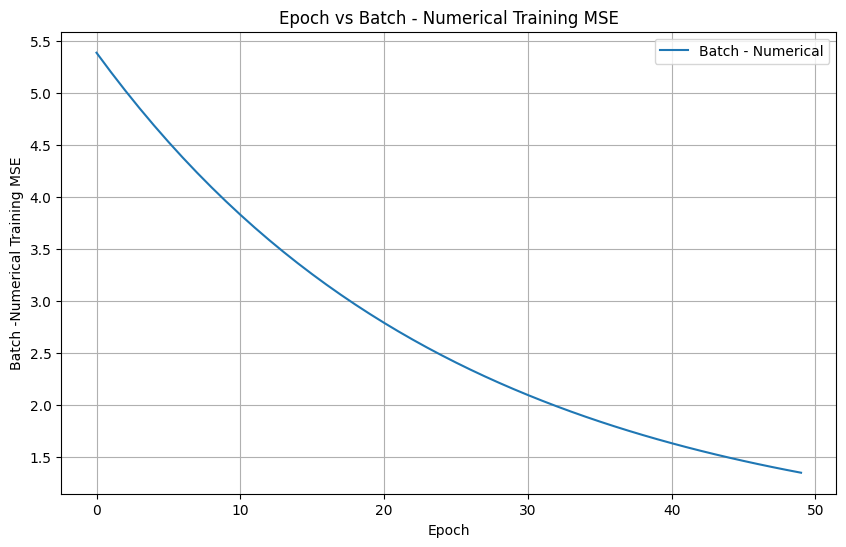

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(train_batch_n, label="Batch - Numerical")


plt.xlabel("Epoch")
plt.ylabel("Batch -Numerical Training MSE")
plt.title("Epoch vs Batch - Numerical Training MSE")

plt.legend()
plt.grid()

plt.show()

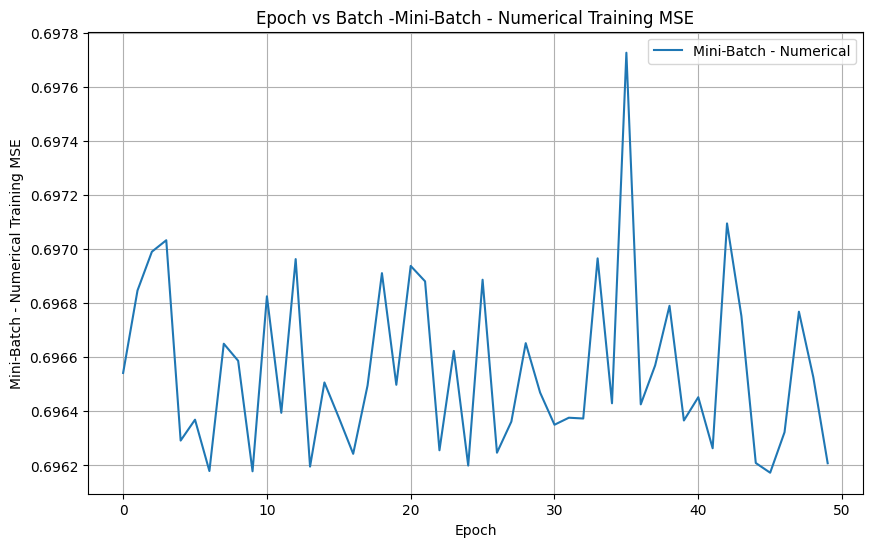

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(train_mini_n, label="Mini-Batch - Numerical")


plt.xlabel("Epoch")
plt.ylabel("Mini-Batch - Numerical Training MSE")
plt.title("Epoch vs Batch -Mini-Batch - Numerical Training MSE")

plt.legend()
plt.grid()

plt.show()

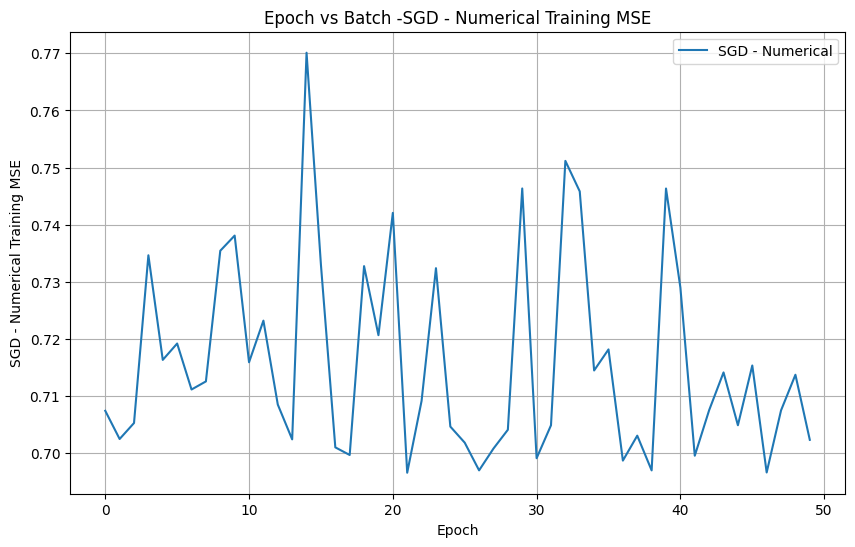

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(train_sgd_n, label="SGD - Numerical")


plt.xlabel("Epoch")
plt.ylabel("SGD - Numerical Training MSE")
plt.title("Epoch vs Batch -SGD - Numerical Training MSE")

plt.legend()
plt.grid()

plt.show()

####  Epoch vs Validation MSE

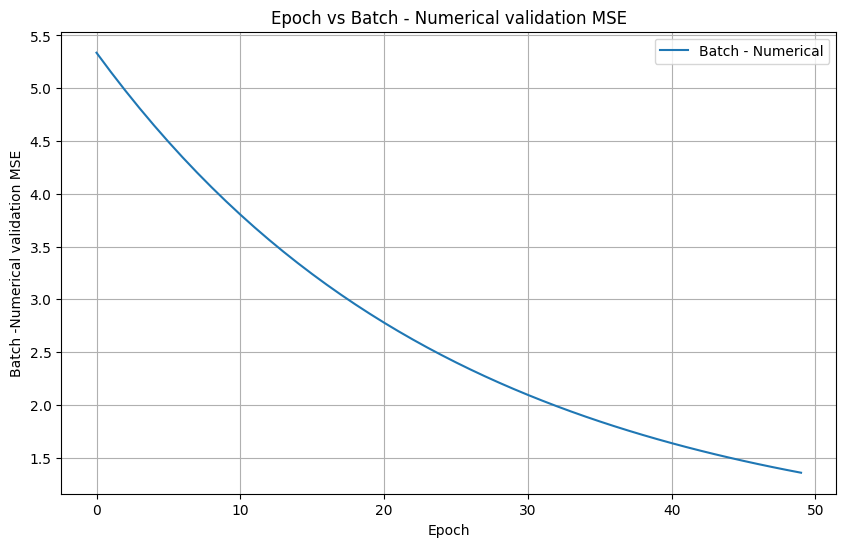

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(val_batch_n, label="Batch - Numerical")


plt.xlabel("Epoch")
plt.ylabel("Batch -Numerical validation MSE")
plt.title("Epoch vs Batch - Numerical validation MSE")

plt.legend()
plt.grid()
plt.show()





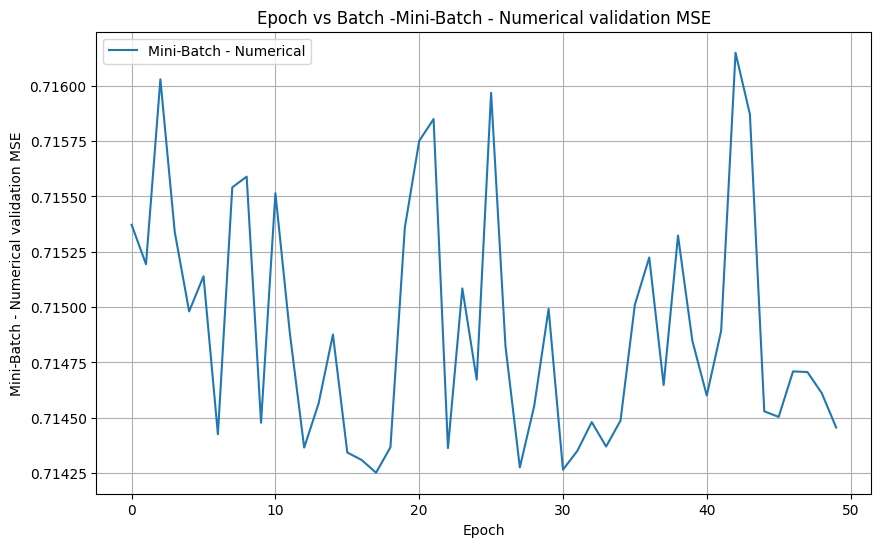

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(val_mini_n, label="Mini-Batch - Numerical")


plt.xlabel("Epoch")
plt.ylabel("Mini-Batch - Numerical validation MSE")
plt.title("Epoch vs Batch -Mini-Batch - Numerical validation MSE")

plt.legend()
plt.grid()

plt.show()

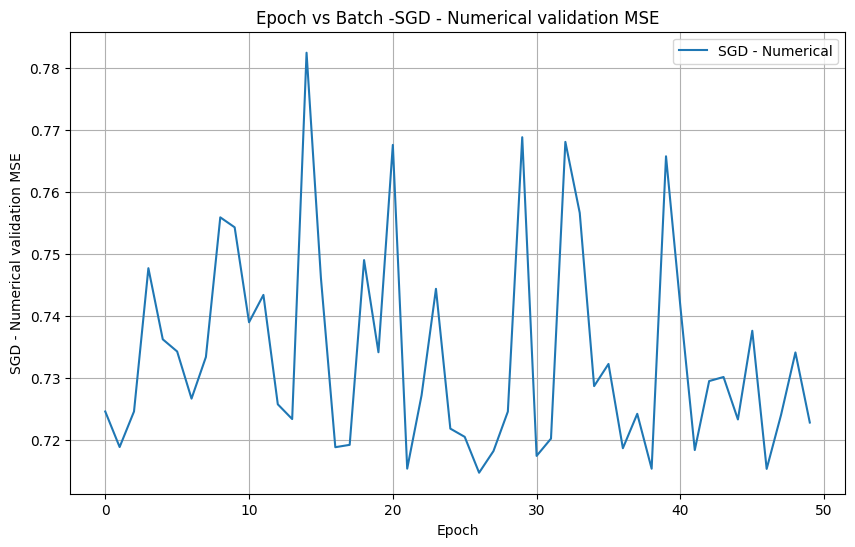

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(val_sgd_n, label="SGD - Numerical")


plt.xlabel("Epoch")
plt.ylabel("SGD - Numerical validation MSE")
plt.title("Epoch vs Batch -SGD - Numerical validation MSE")

plt.legend()
plt.grid()

plt.show()

#### Bar plot comparing execution time

In [ ]:
import time
import pandas as pd
import numpy as np

# Use the same settings
theta_initial = np.array([0.0, 0.0])
learning_rate = 0.01
epochs = 50
batch_size = 32

results = []

# --------------------------------------------------
# 1. Batch GD - Analytical
# --------------------------------------------------

start = time.time()

theta_batch_a, train_batch_a, val_batch_a = batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    analytical_gradient_lr
)

end = time.time()

results.append([
    "Batch GD",
    "Analytical",
    end - start,
    train_batch_a[-1],
    val_batch_a[-1]
])


# --------------------------------------------------
# 2. Batch GD - Numerical
# --------------------------------------------------

start = time.time()

theta_batch_n, train_batch_n, val_batch_n = batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    numerical_gradient_lr
)

end = time.time()

results.append([
    "Batch GD",
    "Numerical",
    end - start,
    train_batch_n[-1],
    val_batch_n[-1]
])


# --------------------------------------------------
# 3. Mini-Batch GD - Analytical
# --------------------------------------------------

start = time.time()

theta_mini_a, train_mini_a, val_mini_a = mini_batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    batch_size,
    analytical_gradient_lr
)

end = time.time()

results.append([
    "Mini-Batch GD",
    "Analytical",
    end - start,
    train_mini_a[-1],
    val_mini_a[-1]
])


# --------------------------------------------------
# 4. Mini-Batch GD - Numerical
# --------------------------------------------------

start = time.time()

theta_mini_n, train_mini_n, val_mini_n = mini_batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    batch_size,
    numerical_gradient_lr
)

end = time.time()

results.append([
    "Mini-Batch GD",
    "Numerical",
    end - start,
    train_mini_n[-1],
    val_mini_n[-1]
])


# --------------------------------------------------
# 5. SGD - Analytical
# --------------------------------------------------

start = time.time()

theta_sgd_a, train_sgd_a, val_sgd_a = stochastic_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    analytical_gradient_lr
)

end = time.time()

results.append([
    "SGD",
    "Analytical",
    end - start,
    train_sgd_a[-1],
    val_sgd_a[-1]
])


# --------------------------------------------------
# 6. SGD - Numerical
# --------------------------------------------------

start = time.time()

theta_sgd_n, train_sgd_n, val_sgd_n = stochastic_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta_initial,
    learning_rate,
    epochs,
    numerical_gradient_lr
)

end = time.time()

results.append([
    "SGD",
    "Numerical",
    end - start,
    train_sgd_n[-1],
    val_sgd_n[-1]
])


# Create comparison dataframe

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Method",
        "Gradient",
        "Execution Time (seconds)",
        "Final Training MSE",
        "Final Validation MSE"
    ]
)

comparison_df

,Method,Gradient,Execution Time (seconds),Final Training MSE,Final Validation MSE
0,Batch GD,Analytical,0.013705,1.344436,1.357710
1,Batch GD,Numerical,0.014726,1.344442,1.357717
2,Mini-Batch GD,Analytical,0.566116,0.696321,0.715053
3,Mini-Batch GD,Numerical,1.267829,0.696354,0.714945
4,SGD,Analytical,9.503816,0.700284,0.716560
5,SGD,Numerical,32.714721,0.716226,0.736194


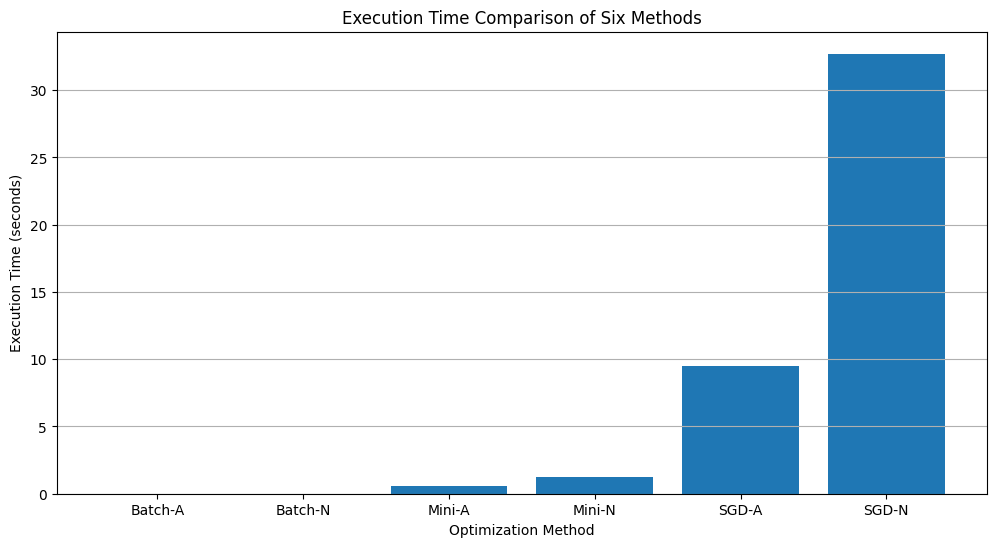

In [ ]:
plt.figure(figsize=(12, 6))

labels = [
    "Batch-A",
    "Batch-N",
    "Mini-A",
    "Mini-N",
    "SGD-A",
    "SGD-N"
]

times = comparison_df["Execution Time (seconds)"]

plt.bar(labels, times)

plt.xlabel("Optimization Method")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison of Six Methods")

plt.grid(axis="y")

plt.show()

#### conclusion:
The experiment compared Batch Gradient Descent, Mini-Batch Gradient Descent, and Stochastic Gradient Descent using both analytical and numerical gradients. The numerical gradient produced results close to the analytical gradient, confirming that the numerical differentiation implementation correctly approximates the analytical derivative.

Batch Gradient Descent provides a stable parameter update because it uses the complete training dataset for every update. Mini-Batch Gradient Descent provides a balance between computational efficiency and stable convergence by using a subset of the training data. Stochastic Gradient Descent updates the parameters using one sample at a time, resulting in faster individual updates but greater variation in the optimization process.

Analytical gradients are significantly more computationally efficient than numerical gradients because numerical differentiation requires additional function evaluations for each parameter. Therefore, although numerical gradients are useful for validating derivative implementations, analytical gradients are generally preferred when training machine learning models.

The training and validation MSE plots show the convergence behavior of the six approaches. The final comparison of execution time, training MSE, validation MSE, and learned parameters provides a practical evaluation of the optimization methods.